# Missing and spurious interactions and the reconstruction of complex networks

---

**Students**
* Gabriele Bellavia (Badge No. )
* Sofia Di Lucia (Badge No. 2149752)

**Academic Year:** 2025–2026

---

- [Ref article](https://www.pnas.org/doi/10.1073/pnas.0908366106)
- I dataset citati dovrebbero essere questi:
    1. [karate club (23)](https://networkrepository.com/soc-karate.php)
    2. [dolphins (24)](https://networkrepository.com/dolphins.php)
    3. [air transportation network of Eastern Europe (25)](https://www.oag.com/flight-data-sets)
    4. [Caenorhabditis elegans (26)](http://konect.cc/networks/dimacs10-celegansneural/)
    5. [metabolic network of Escherichia coli (27, 28)](http://bigg.ucsd.edu/models/iJR904)
- Altri dataset:
    1. [SNAP](https://snap.stanford.edu/data/#socnets)
    2. [Network Repository](https://networkrepository.com/)
- Software and libraries:
    1. [igraph](https://igraph.org/)
    2. [networkx](https://networkx.org/en/)
    3. [graphtool](https://graph-tool.skewed.de/)
    4. [Gephi](https://gephi.org/)

## Karate Club network: missing and spurious interaction analysis

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import math as m
import copy as c

np.random.seed(123)

## Inspecting network

We start to work with Zachary Karate club network, which is a small, non-directed network. The network is already in networkx package, thus we consider it as the true network.

We want to work with three distinct objects: the true network, the observed one (obtained by removing random links) and the set of randomly removed links.

Graph named "Zachary's Karate Club" with 34 nodes and 78 edges


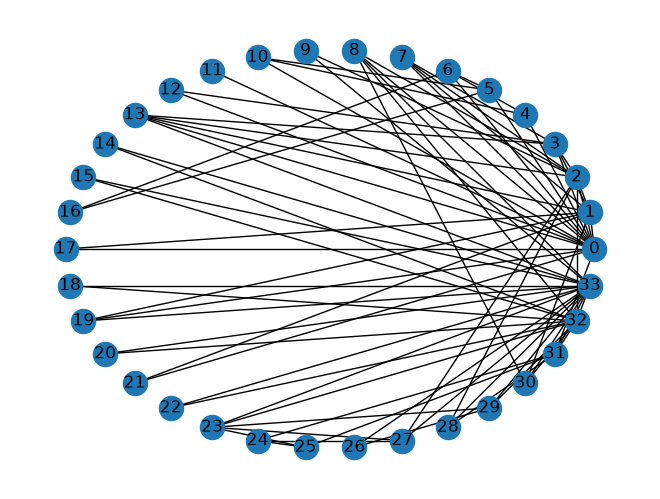

In [2]:
G = nx.karate_club_graph()
print(G)
nx.draw_circular(G, with_labels=True)
plt.show()

In [3]:
#list(G.nodes)

We want to work with unweighted networks, thus we neglect the weights.

In [4]:
AT = nx.adjacency_matrix(G, weight=None).toarray()

### Generating hypothetical observation

In [5]:
AO = AT.copy()
prob = 0.05 #switching probability
for i in range(AT.shape[0]):
    for j in range(i+1, AT.shape[1]):
        if(np.random.uniform(0,1) > 1-prob):
            AO[i,j] = 1 - AT[i,j]
            AO[j,i] = AO[i,j]

AO_G = nx.from_numpy_array(AO)

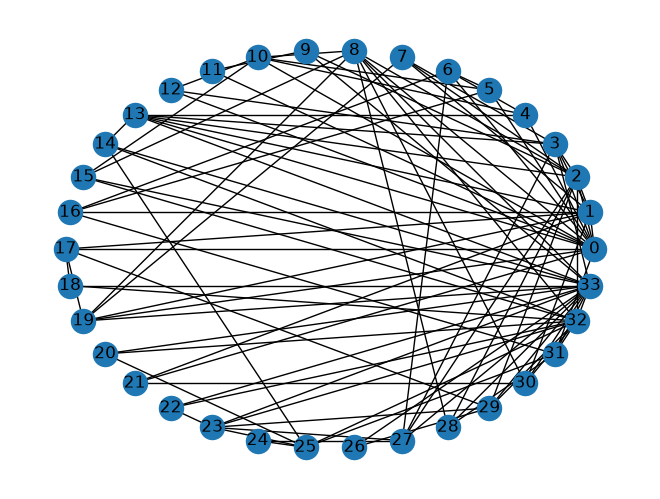

In [6]:
nx.draw_circular(nx.from_numpy_array(AO), with_labels=True)

## Metropolis Estimation

We start by placing each of the N nodes in a group, which we choose
with uniform probability from a set of N possible groups (that is, there are
as many groups as nodes). In general, some of these N groups will be empty
after the initial node assignment

In [7]:
# creating the N possible groups
N = len(G.nodes)
P0 = {}
for i in range(N):
    P0.update({f'group {i}': []})

# placing each node in a group
assign = np.array(np.random.randint(0, N, N, dtype=int))
for i in G.nodes:
    group_ass = assign[i]
    P0[f'group {group_ass}'].append(i)

In [8]:
# function to calculate r_ab
def compute_r_ab(partition, alpha, beta):
    alpha_size = len(partition[f'group {alpha}'])
    beta_size = len(partition[f'group {beta}'])
    if(alpha==beta):
        return  alpha_size * (alpha_size - 1) // 2
    else:
        return alpha_size * beta_size

In [10]:
# function to calculate lO_ab
def compute_lO_ab(partition, alpha, beta):
    lO_ab = 0
    if(alpha == beta):
        for i, el in enumerate(partition[f'group {alpha}']):
            for j in partition[f'group {alpha}'][i+1:]:
                if AO_G.has_edge(el, j):
                    lO_ab += 1
    else:
        for i in partition[f'group {alpha}']:
            for j in partition[f'group {beta}']:
                if AO_G.has_edge(i,j):
                    lO_ab += 1
    return lO_ab

In [11]:
# function to compute H(P)
def compute_HP(partition):
    sum_ab = 0
    for i in range(0, len(partition)):
        for j in range(i, len(partition)):
            r_ab = compute_r_ab(partition, i, j)
            lO_ab = compute_lO_ab(partition, i, j)
            f_ab = m.log(r_ab + 1) + m.log(m.comb(r_ab, lO_ab))
            sum_ab += f_ab 
    return sum_ab

In [44]:
P_old = c.deepcopy(P0)
for step in range(10000):
    rand_node = np.random.randint(0, N, dtype=int)
    # beta is the proposed move group, VEDERE MEGLIO CASO beta = alpha
    alpha = int(next(key for key, nodes in P_old.items() if rand_node in nodes).split()[-1])
    beta = np.random.randint(0, N, dtype=int)
    while(beta == alpha): beta = np.random.randint(0, N, dtype=int)
    #print(f'Selected node: {rand_node}. From group {alpha} move to group {beta}')
    P_new = c.deepcopy(P_old)
    P_new[f'group {alpha}'].remove(rand_node)
    P_new[f'group {beta}'].append(rand_node)
    H0 = compute_HP(P_old)
    H1 = compute_HP(P_new)
    DH = H1 - H0
    if(DH < 0):
        P_old = P_new
    elif(m.exp(-DH)>np.random.uniform(0,1))
        P_old = P_new
    #print(f'{DH},\n {P_old},\n {P_new}')
        

In [ ]:
#Next steps: sampling, steady state, burn in, fluctuations, ecc.

(pag.2 article):<br>
1. we assume that each of these networks is the “true” network $A^T$ and is error free
2. We then generate hypothetical observations $A^O$ by adding or removing random connections from $A^T$
3. We evaluate the ability of our approach to recover the features of the true network

- **missing(\spurious) interactions**:
1. we generate observed networks $A^O$ by removing(\adding) random links from the true network $A^T$
2. We then estimate the link reliability $R^L_{ij}$ for each of these false negatives ($A^O_{ij} = 0$ and $A^T_{ij} = 1$), as well as for the
true negatives ($A^O_{ij} = 0$ and $A^T_{ij} = 0$) (\spurious: false positive ($A^O_{ij} = 1$ and $A^T_{ij} = 0$) is ranked lower than a true positive ($A^O_{ij} = 1$ and $A^T_{ij} = 1$).)
3. We measure the algorithm’s ability to identify missing interactions by ranking the reliabilities (in decreasing order) and calculating the probability that a false negative has a higher ranking than a true negative.

At each step we select a random node and attempt to move it to a randomly selected group:
- if $\Delta H \le 0 \rightarrow$ we accept the move
- if $\Delta H \ge 0 \rightarrow$ we accep the move with $P = e^{- \Delta H}$
with

$$H(P) = \sum_{\alpha \le \beta} \Big[\ln(r_{\alpha \beta}+1) + \ln\binom{r_{\alpha \beta}}{l^O_{\alpha \beta}} \Big]
$$
where:
- $\alpha$ and $\beta$ are groups
- $r_{\alpha \beta}$ is the maximum possible number of links between $\alpha$ and $\beta$
- $l^O_{\alpha \beta}$ is the number of links in the observed network between $\alpha$ and $\beta$